In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_curve, roc_auc_score, accuracy_score, precision_score,
                              recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

sns.set(style="whitegrid")

In [3]:
# The Digits dataset (public, from UCI's Optical Recognition of Handwritten
# Digits, built into scikit-learn) contains 1797 samples of 8x8 pixel
# images of handwritten digits (0-9), flattened into 64 numeric features
# (pixel intensity values 0-16).
#
# To turn this into a CLASSIFICATION problem with realistic IMBALANCE
# (needed for this task), we convert it into a BINARY problem:
#   target = 1  if the digit is "9"
#   target = 0  otherwise (digits 0-8)
# Since digit 9 is just 1 of 10 roughly-equal classes, this naturally
# creates a ~90% / ~10% imbalanced dataset - a realistic scenario
# (e.g. similar to fraud detection, rare disease detection, etc.)

digits = load_digits()
X = digits.data
y = (digits.target == 9).astype(int)

print("Total samples:", len(y))
print("Number of features:", X.shape[1])
print("Feature meaning: 64 pixel intensity values (8x8 image, flattened)")
print("\nClass counts (0 = not-9, 1 = digit 9):", np.bincount(y))
print("Class 1 proportion:", round(np.mean(y)*100, 2), "%")

Total samples: 1797
Number of features: 64
Feature meaning: 64 pixel intensity values (8x8 image, flattened)

Class counts (0 = not-9, 1 = digit 9): [1617  180]
Class 1 proportion: 10.02 %


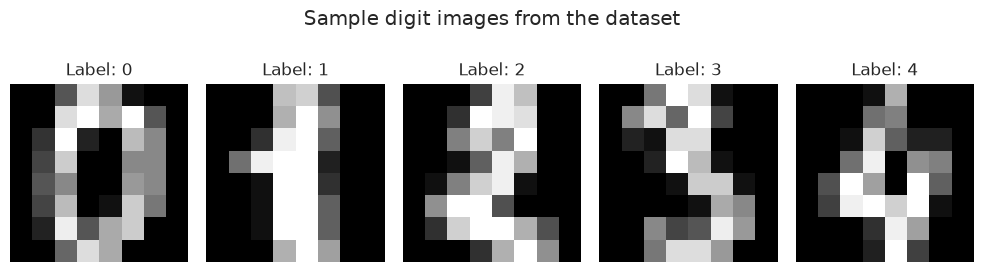

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(10,3))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis('off')
plt.suptitle("Sample digit images from the dataset")
plt.tight_layout()
plt.savefig('../screenshots/sample_digits.png', dpi=150)
plt.show()

In [5]:
# stratify=y keeps the same class proportion (~10% class 1) in both
# train and test sets, which is important for imbalanced data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class counts:", np.bincount(y_train))
print("Test class counts:", np.bincount(y_test))

# Scale features (pixel values 0-16) to mean=0, std=1
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("\nScaling done.")

Train shape: (1347, 64)  Test shape: (450, 64)
Train class counts: [1212  135]
Test class counts: [405  45]

Scaling done.


In [6]:
# Logistic Regression is used as the baseline classifier - it's simple,
# fast, and outputs well-calibrated probabilities (needed for ROC-AUC).
baseline_model = LogisticRegression(max_iter=2000, random_state=42)
baseline_model.fit(X_train_s, y_train)

y_pred = baseline_model.predict(X_test_s)
y_proba = baseline_model.predict_proba(X_test_s)[:, 1]

print("Baseline Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Baseline Precision:", round(precision_score(y_test, y_pred), 4))
print("Baseline Recall:", round(recall_score(y_test, y_pred), 4))
print("Baseline F1-Score:", round(f1_score(y_test, y_pred), 4))

Baseline Accuracy: 0.98
Baseline Precision: 0.9737
Baseline Recall: 0.8222
Baseline F1-Score: 0.8916


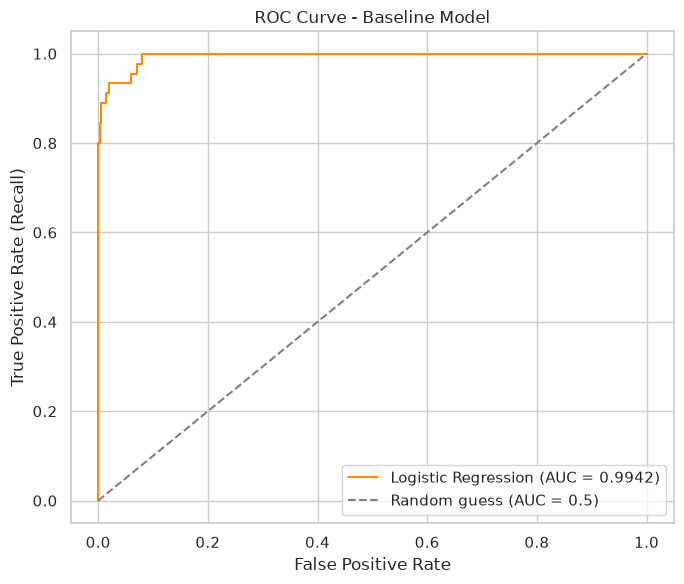

ROC-AUC Score: 0.9942


In [7]:
# ROC Curve plots True Positive Rate (Recall) vs False Positive Rate at
# every possible decision threshold. ROC-AUC summarizes this into a
# single number: the probability the model ranks a random positive
# sample higher than a random negative sample (1.0 = perfect, 0.5 = random).

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})', color='darkorange')
plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Baseline Model')
plt.legend()
plt.tight_layout()
plt.savefig('../screenshots/roc_curve_baseline.png', dpi=150)
plt.show()

print("ROC-AUC Score:", round(auc_score, 4))

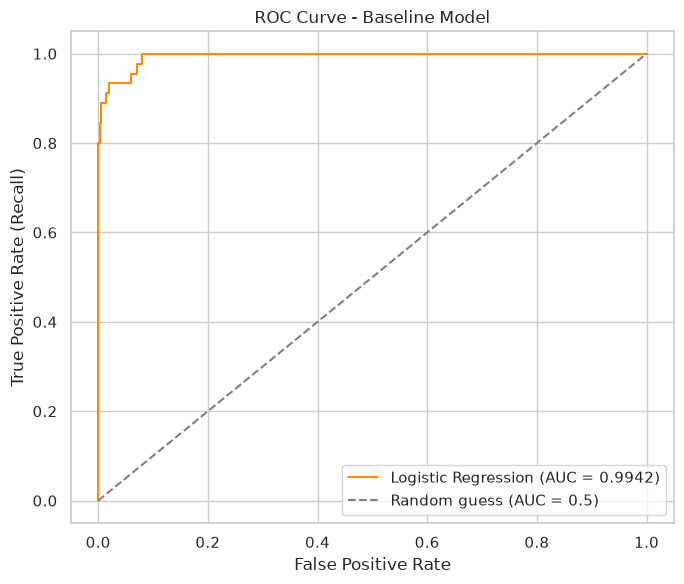

ROC-AUC Score: 0.9942


In [8]:
# ROC Curve plots True Positive Rate (Recall) vs False Positive Rate at
# every possible decision threshold. ROC-AUC summarizes this into a
# single number: the probability the model ranks a random positive
# sample higher than a random negative sample (1.0 = perfect, 0.5 = random).

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})', color='darkorange')
plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Baseline Model')
plt.legend()
plt.tight_layout()
plt.savefig('../screenshots/roc_curve_baseline.png', dpi=150)
plt.show()

print("ROC-AUC Score:", round(auc_score, 4))

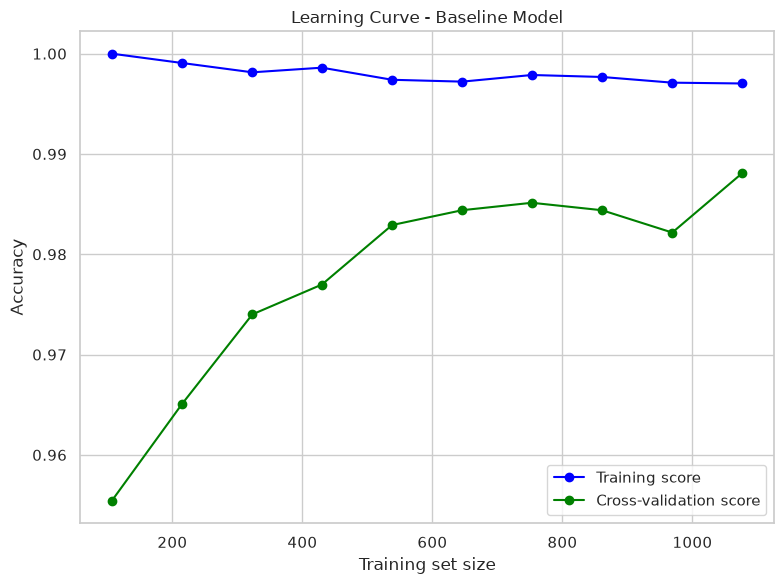

Final training score: 0.997
Final validation score: 0.9881


In [9]:
# A learning curve shows training score and cross-validation score as
# the amount of training data increases. It helps diagnose:
#   - Underfitting: both scores are low and close together
#   - Overfitting: training score high, validation score much lower (big gap)
#   - Good generalization: both scores converge to a high value

train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=2000, random_state=42),
    X_train_s, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='accuracy', random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
plt.plot(train_sizes, val_mean, 'o-', color='green', label='Cross-validation score')
plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.title('Learning Curve - Baseline Model')
plt.legend()
plt.tight_layout()
plt.savefig('../screenshots/learning_curve.png', dpi=150)
plt.show()

print("Final training score:", round(train_mean[-1], 4))
print("Final validation score:", round(val_mean[-1], 4))

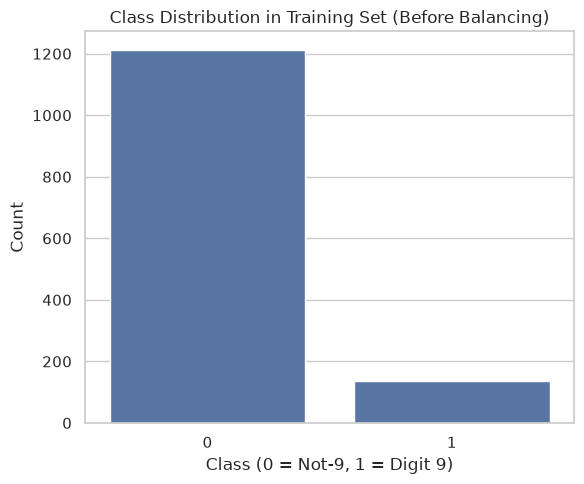

Training class counts: [1212  135]
Imbalance ratio (majority:minority) = 8.98 : 1


In [10]:
plt.figure(figsize=(6,5))
sns.countplot(x=y_train)
plt.title('Class Distribution in Training Set (Before Balancing)')
plt.xlabel('Class (0 = Not-9, 1 = Digit 9)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../screenshots/class_imbalance.png', dpi=150)
plt.show()

print("Training class counts:", np.bincount(y_train))
ratio = np.bincount(y_train)[0] / np.bincount(y_train)[1]
print(f"Imbalance ratio (majority:minority) = {ratio:.2f} : 1")

In [11]:
# SMOTE (Synthetic Minority Over-sampling Technique) creates new SYNTHETIC
# minority-class samples by interpolating between existing minority
# samples and their nearest neighbors - unlike simple duplication, this
# adds variety rather than just repeating the same points.
# IMPORTANT: SMOTE is applied ONLY to the training set, never the test set,
# to avoid data leakage / unrealistic evaluation.

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_s, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE: ", np.bincount(y_train_smote))

smote_model = LogisticRegression(max_iter=2000, random_state=42)
smote_model.fit(X_train_smote, y_train_smote)

y_pred_smote = smote_model.predict(X_test_s)
y_proba_smote = smote_model.predict_proba(X_test_s)[:, 1]

print("\n--- SMOTE Model Performance (on original, untouched test set) ---")
print("Accuracy:", round(accuracy_score(y_test, y_pred_smote), 4))
print("Precision:", round(precision_score(y_test, y_pred_smote), 4))
print("Recall:", round(recall_score(y_test, y_pred_smote), 4))
print("F1-Score:", round(f1_score(y_test, y_pred_smote), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_smote), 4))

Before SMOTE: [1212  135]
After SMOTE:  [1212 1212]

--- SMOTE Model Performance (on original, untouched test set) ---
Accuracy: 0.9778
Precision: 0.8723
Recall: 0.9111
F1-Score: 0.8913
ROC-AUC: 0.9937


In [12]:
# class_weight='balanced' automatically re-weights the loss function so
# that mistakes on the minority class are penalized more heavily,
# proportional to class frequency - no synthetic data is created, the
# original training data is used as-is.

cw_model = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
cw_model.fit(X_train_s, y_train)

y_pred_cw = cw_model.predict(X_test_s)
y_proba_cw = cw_model.predict_proba(X_test_s)[:, 1]

print("--- Class-Weighted Model Performance ---")
print("Accuracy:", round(accuracy_score(y_test, y_pred_cw), 4))
print("Precision:", round(precision_score(y_test, y_pred_cw), 4))
print("Recall:", round(recall_score(y_test, y_pred_cw), 4))
print("F1-Score:", round(f1_score(y_test, y_pred_cw), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_cw), 4))

--- Class-Weighted Model Performance ---
Accuracy: 0.9711
Precision: 0.82
Recall: 0.9111
F1-Score: 0.8632
ROC-AUC: 0.9924


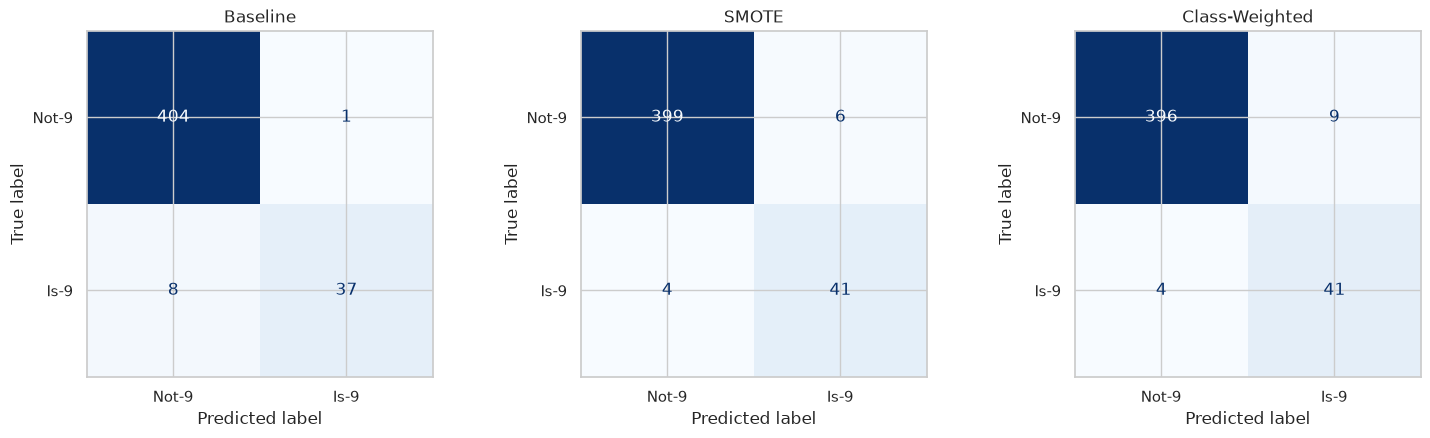

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.5))

models_preds = [
    ("Baseline", y_pred),
    ("SMOTE", y_pred_smote),
    ("Class-Weighted", y_pred_cw)
]

for ax, (name, preds) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not-9','Is-9'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.savefig('../screenshots/confusion_matrices_comparison.png', dpi=150)
plt.show()

In [14]:
results = pd.DataFrame({
    'Model': ['Baseline', 'SMOTE', 'Class-Weighted'],
    'Accuracy': [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_smote), accuracy_score(y_test, y_pred_cw)],
    'Precision': [precision_score(y_test, y_pred), precision_score(y_test, y_pred_smote), precision_score(y_test, y_pred_cw)],
    'Recall': [recall_score(y_test, y_pred), recall_score(y_test, y_pred_smote), recall_score(y_test, y_pred_cw)],
    'F1-Score': [f1_score(y_test, y_pred), f1_score(y_test, y_pred_smote), f1_score(y_test, y_pred_cw)],
    'ROC-AUC': [roc_auc_score(y_test, y_proba), roc_auc_score(y_test, y_proba_smote), roc_auc_score(y_test, y_proba_cw)],
})
results = results.round(4)
print(results)

            Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0        Baseline    0.9800     0.9737  0.8222    0.8916   0.9942
1           SMOTE    0.9778     0.8723  0.9111    0.8913   0.9937
2  Class-Weighted    0.9711     0.8200  0.9111    0.8632   0.9924
